In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("Libraries imported and seeds set.")

Libraries imported and seeds set.


In [3]:
def generate_data(N=10000, p=100, noise_level=0.15, correlation=0.5):
    """
    Generates synthetic binary classification data.

    Args:
        N: Sample size
        p: Number of features
        noise_level: Percentage of labels to flip (c)
        correlation: Target average correlation between features
    """
    # 1. Generate Covariance Matrix for correlated features
    # Diagonal is 1, off-diagonal is 'correlation'
    cov_matrix = np.full((p, p), correlation)
    np.fill_diagonal(cov_matrix, 1.0)

    # Generate X ~ N(0, Sigma)
    mean = np.zeros(p)
    X = np.random.multivariate_normal(mean, cov_matrix, size=N)

    # 2. Generate True Weights (beta)
    # Random weights from normal distribution
    beta = np.random.normal(0, 1, size=p)

    # 3. Calculate Probabilities via Logistic Sigmoid
    logits = X @ beta
    probs = 1 / (1 + np.exp(-logits))

    # 4. Generate Initial Labels y
    y = np.random.binomial(1, probs)

    # 5. Apply Label Noise (Flip c% of labels)
    n_flip = int(noise_level * N)
    flip_indices = np.random.choice(np.arange(N), size=n_flip, replace=False)
    y[flip_indices] = 1 - y[flip_indices] # Flip 0 to 1, 1 to 0

    # Convert to PyTorch tensors
    X_tensor = torch.tensor(X, dtype=torch.float32)
    y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(1) # Shape (N, 1)

    return X_tensor, y_tensor

# Generate the full dataset
X, y = generate_data(N=10000, p=100, noise_level=0.15)
print(f"Data Generated: X shape {X.shape}, y shape {y.shape}")

Data Generated: X shape torch.Size([10000, 100]), y shape torch.Size([10000, 1])


In [4]:
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset

# 1. First Split: Separate Training Data (60%) from the rest (40%)
# Total N = 10,000. We want 6,000 for training.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    train_size=6000,  # Explicitly setting 6000 as per slides
    random_state=42
)

# 2. Second Split: Separate Validation (20%) and Test (20%)
# X_temp contains 4,000 samples. We split it 50/50 to get 2,000 each.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,    # 50% of the remaining 4000 = 2000
    random_state=42
)

# 3. Wrap in PyTorch Datasets
# We do NOT create DataLoaders here because the Grid Search cell
# needs to create its own DataLoaders with different batch sizes.
train_dataset = TensorDataset(X_train, y_train)
val_dataset = TensorDataset(X_val, y_val)
test_dataset = TensorDataset(X_test, y_test)

# 4. Verification
print(f"Data Split Statistics:")
print(f"Training Set:   {len(X_train)} samples ({len(X_train)/len(X):.0%})")
print(f"Validation Set: {len(X_val)} samples ({len(X_val)/len(X):.0%})")
print(f"Test Set:       {len(X_test)} samples ({len(X_test)/len(X):.0%})")

Data Split Statistics:
Training Set:   6000 samples (60%)
Validation Set: 2000 samples (20%)
Test Set:       2000 samples (20%)


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from sklearn.metrics import roc_auc_score
import pandas as pd # Used for a nice output table

class DynamicMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(DynamicMLP, self).__init__()
        # Input Layer -> Hidden Layer
        self.layer1 = nn.Linear(input_dim, hidden_dim)
        # Hidden Layer -> Output (Scalar)
        self.layer2 = nn.Linear(hidden_dim, 1)
        # Activation function
        self.activation = nn.ReLU()

        # Proper Initialization (Crucial for convergence/stability)
        # Kaiming/He Init is standard for ReLU layers
        nn.init.kaiming_normal_(self.layer1.weight, mode='fan_in', nonlinearity='relu')
        nn.init.zeros_(self.layer1.bias)

        # Xavier/Glorot Init is standard for the output layer
        nn.init.xavier_uniform_(self.layer2.weight)
        nn.init.zeros_(self.layer2.bias)

    def forward(self, x):
        x = self.activation(self.layer1(x))
        # We return logits (raw scores) because we use BCEWithLogitsLoss
        return self.layer2(x)

print("Model class defined successfully.")

Model class defined successfully.


In [6]:
def run_experiment(config, train_ds, val_ds):
    """
    Trains a model with specific hyperparameters and returns final metrics.
    """
    # Unpack configuration dictionary
    h_dim = config['hidden_dim']
    lr = config['lr']
    bs = config['batch_size']
    epochs = config['epochs']

    # Create Local DataLoaders specific to this batch size (bs)
    t_loader = DataLoader(train_ds, batch_size=bs, shuffle=True)
    v_loader = DataLoader(val_ds, batch_size=bs, shuffle=False)

    # Initialize Model & Optimizer
    model = DynamicMLP(input_dim=100, hidden_dim=h_dim)
    criterion = nn.BCEWithLogitsLoss() # More stable than Sigmoid + BCELoss
    optimizer = optim.SGD(model.parameters(), lr=lr)

    # --- Training Phase ---
    model.train()
    for epoch in range(epochs):
        for inputs, labels in t_loader:
            optimizer.zero_grad()           # Clear gradients
            outputs = model(inputs)         # Forward pass
            loss = criterion(outputs, labels)
            loss.backward()                 # Backward pass
            optimizer.step()                # Update weights

    # --- Evaluation Phase (Validation Set) ---
    model.eval()
    val_targets = []
    val_preds = []
    total_val_loss = 0

    with torch.no_grad(): # Disable gradient calculation for speed
        for inputs, labels in v_loader:
            outputs = model(inputs)
            total_val_loss += criterion(outputs, labels).item() * inputs.size(0)

            # Apply Sigmoid to get probability (0-1) for AUC calc
            probs = torch.sigmoid(outputs)
            val_targets.extend(labels.numpy())
            val_preds.extend(probs.numpy())

    avg_val_loss = total_val_loss / len(val_ds)
    val_auc = roc_auc_score(val_targets, val_preds)

    return avg_val_loss, val_auc

print("Experiment runner defined.")

Experiment runner defined.


In [8]:
# List of dictionaries, each representing one experiment
experiments = [
    # 1. Baseline
    {'hidden_dim': 32,  'lr': 0.01, 'batch_size': 64,  'epochs': 30},
    # 2. Wider Network + Higher Learning Rate
    {'hidden_dim': 128, 'lr': 0.1,  'batch_size': 64,  'epochs': 30},
    # 3. Smaller Batch Size (More noisy updates, often better generalization)
    {'hidden_dim': 128, 'lr': 0.01, 'batch_size': 32,  'epochs': 30},
    # 4. Large Batch + Wide Network (Approximates full gradient descent)
    {'hidden_dim': 512, 'lr': 0.1,  'batch_size': 256, 'epochs': 30},
    # 5. Very High Learning Rate (Risk of instability)
    {'hidden_dim': 32,  'lr': 0.5,  'batch_size': 64,  'epochs': 30},
]

print(f"Grid defined with {len(experiments)} configurations.")

Grid defined with 5 configurations.


In [9]:
results = []
print(f"Starting Grid Search on {len(experiments)} configurations...\n")

for i, conf in enumerate(experiments):
    # Run the experiment
    loss, auc = run_experiment(conf, train_dataset, val_dataset)

    # Store results
    res = conf.copy()
    res['val_loss'] = loss
    res['val_auc'] = auc
    results.append(res)

    print(f"Exp {i+1}: Hidden={conf['hidden_dim']}, LR={conf['lr']}, Batch={conf['batch_size']} -> Val Loss: {loss:.4f}, AUC: {auc:.4f}")

# Display Leaderboard
df_results = pd.DataFrame(results)
print("\n" + "="*40)
print(" FINAL LEADERBOARD (Sorted by Best AUC)")
print("="*40)
# Sort values so the best model is at the top
print(df_results.sort_values(by='val_auc', ascending=False).to_string(index=False))

Starting Grid Search on 5 configurations...

Exp 1: Hidden=32, LR=0.01, Batch=64 -> Val Loss: 0.5545, AUC: 0.8009
Exp 2: Hidden=128, LR=0.1, Batch=64 -> Val Loss: 0.8434, AUC: 0.7642
Exp 3: Hidden=128, LR=0.01, Batch=32 -> Val Loss: 0.5443, AUC: 0.8152
Exp 4: Hidden=512, LR=0.1, Batch=256 -> Val Loss: 0.6318, AUC: 0.7927
Exp 5: Hidden=32, LR=0.5, Batch=64 -> Val Loss: 0.6710, AUC: 0.7782

 FINAL LEADERBOARD (Sorted by Best AUC)
 hidden_dim   lr  batch_size  epochs  val_loss  val_auc
        128 0.01          32      30  0.544264 0.815219
         32 0.01          64      30  0.554486 0.800946
        512 0.10         256      30  0.631801 0.792733
         32 0.50          64      30  0.671018 0.778190
        128 0.10          64      30  0.843353 0.764196


Retraining Best Model: Hidden=128, LR=0.01, Batch=32...


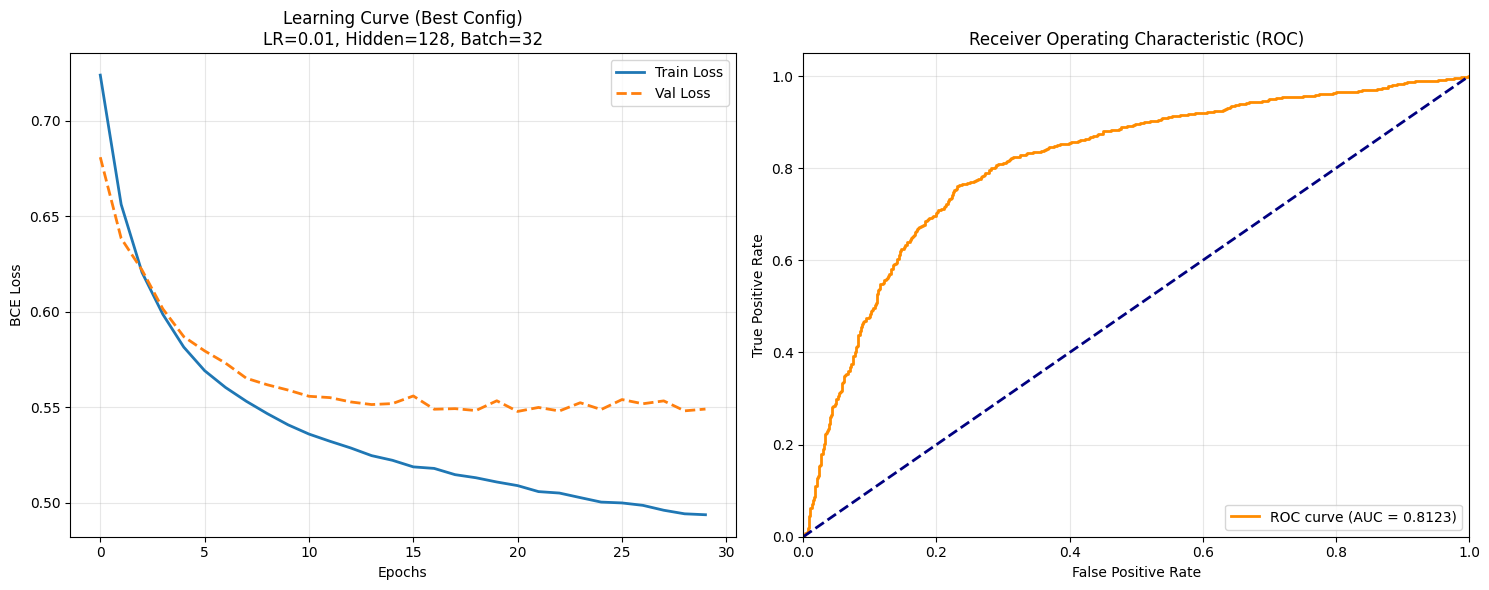

In [11]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Retrieve Best Configuration
# ==========================================
# We grab the top row from the sorted dataframe 'df_results'
best_row = df_results.sort_values(by='val_auc', ascending=False).iloc[0]

h_dim = int(best_row['hidden_dim'])
lr = best_row['lr']
bs = int(best_row['batch_size'])
epochs = int(best_row['epochs'])

print(f"Retraining Best Model: Hidden={h_dim}, LR={lr}, Batch={bs}...")

# 2. Retrain to Capture History
# ==========================================
# Re-create loaders for the winning batch size
t_loader = DataLoader(train_dataset, batch_size=bs, shuffle=True)
v_loader = DataLoader(val_dataset, batch_size=bs, shuffle=False)

# Re-init model
model = DynamicMLP(input_dim=100, hidden_dim=h_dim)
optimizer = optim.SGD(model.parameters(), lr=lr)
criterion = nn.BCEWithLogitsLoss()

# Lists to store per-epoch history
history = {'train_loss': [], 'val_loss': []}

for epoch in range(epochs):
    # --- Training Step ---
    model.train()
    running_loss = 0
    for inputs, labels in t_loader:
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    history['train_loss'].append(running_loss / len(train_dataset))

    # --- Validation Step ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for inputs, labels in v_loader:
            outputs = model(inputs)
            val_loss += criterion(outputs, labels).item() * inputs.size(0)
    history['val_loss'].append(val_loss / len(val_dataset))

# 3. Calculate ROC Curve Data
# ==========================================
model.eval()
y_true = []
y_scores = []

with torch.no_grad():
    for inputs, labels in v_loader:
        outputs = model(inputs)
        probs = torch.sigmoid(outputs) # Convert logits to probability
        y_true.extend(labels.numpy())
        y_scores.extend(probs.numpy())

fpr, tpr, thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)

# 4. Plotting
# ==========================================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Plot 1: Loss Curves
ax1.plot(history['train_loss'], label='Train Loss', linewidth=2)
ax1.plot(history['val_loss'], label='Val Loss', linewidth=2, linestyle='--')
ax1.set_title(f'Learning Curve (Best Config)\nLR={lr}, Hidden={h_dim}, Batch={bs}')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('BCE Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Plot 2: ROC Curve
ax2.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax2.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax2.set_xlim([0.0, 1.0])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('False Positive Rate')
ax2.set_ylabel('True Positive Rate')
ax2.set_title('Receiver Operating Characteristic (ROC)')
ax2.legend(loc="lower right")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()